In [1]:
"""
Thresholding y Binarización
Este notebook introduce el thresholding como la forma más simple de segmentación de imágenes.
Partimos de imágenes en escala de grises y las convertimos en máscaras binarias separando el primer plano del fondo mediante valores de intensidad. 
Exploramos el thresholding manual, la interpretación basada en histogramas, el método de Otsu y el efecto del ruido en la calidad de la segmentación.
Objetivos de aprendizaje
- Comprender qué es la thresholding
- Aplicar la thresholding manual y automática
- Interpretar la segmentación mediante histogramas de imagen
- Comprender conceptualmente el método de Otsu
- Evaluar la segmentación comparándola con datos sintéticos de referencia
- Reconocer las limitaciones de la thresholding en condiciones de ruido
Contexto de la imagen científica
La thresholding se utiliza ampliamente en la imagen científica como primer paso para:
- Separación de poros y matriz en micro-CT
- Detección de partículas
- Segmentación de fase
- Generación de máscaras binarias para análisis cuantitativo
"""

'\nThresholding y Binarización\nEste notebook introduce el thresholding como la forma más simple de segmentación de imágenes.\nPartimos de imágenes en escala de grises y las convertimos en máscaras binarias separando el primer plano del fondo mediante valores de intensidad. \nExploramos el thresholding manual, la interpretación basada en histogramas, el método de Otsu y el efecto del ruido en la calidad de la segmentación.\nObjetivos de aprendizaje\n- Comprender qué es la thresholding\n- Aplicar la thresholding manual y automática\n- Interpretar la segmentación mediante histogramas de imagen\n- Comprender conceptualmente el método de Otsu\n- Evaluar la segmentación comparándola con datos sintéticos de referencia\n- Reconocer las limitaciones de la thresholding en condiciones de ruido\nContexto de la imagen científica\nLa thresholding se utiliza ampliamente en la imagen científica como primer paso para:\n- Separación de poros y matriz en micro-CT\n- Detección de partículas\n- Segmentaci

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data, filters, util
from skimage.draw import disk, rectangle
from skimage.metrics import adapted_rand_error

In [3]:
def show_image(image, title="", cmap="gray"):
    plt.figure(figsize=(5, 5))
    plt.imshow(image, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()


def show_histogram(image, threshold=None, title="Histogram"):
    plt.figure(figsize=(6, 4))
    plt.hist(image.ravel(), bins=256)
    if threshold is not None:
        plt.axvline(threshold, linestyle="--")
    plt.title(title)
    plt.xlabel("Intensity")
    plt.ylabel("Pixel count")
    plt.show()


def dice_score(gt, pred):
    gt = gt.astype(bool)
    pred = pred.astype(bool)
    intersection = np.logical_and(gt, pred).sum()
    denom = gt.sum() + pred.sum()
    if denom == 0:
        return 1.0
    return 2 * intersection / denom


def iou_score(gt, pred):
    gt = gt.astype(bool)
    pred = pred.astype(bool)
    intersection = np.logical_and(gt, pred).sum()
    union = np.logical_or(gt, pred).sum()
    if union == 0:
        return 1.0
    return intersection / union


def evaluate_segmentation(gt, pred):
    print(f"Dice score: {dice_score(gt, pred):.4f}")
    print(f"IoU score:  {iou_score(gt, pred):.4f}")

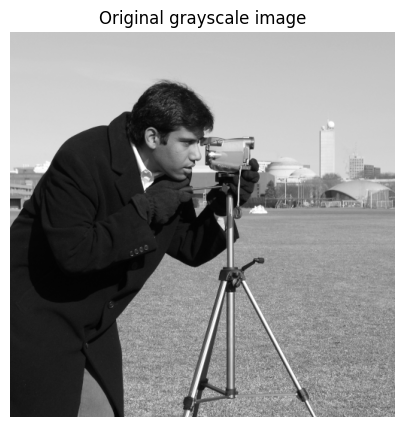

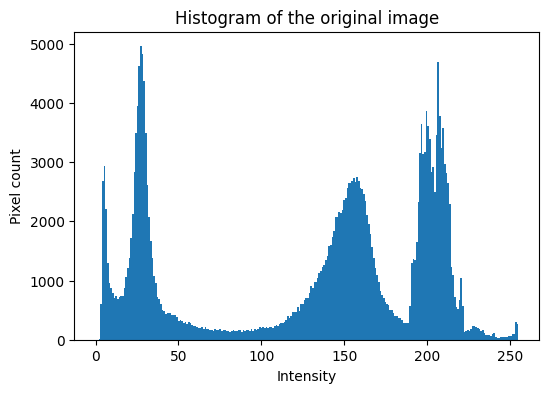

In [4]:
# Load example grayscale image
image = data.camera()

show_image(image, "Original grayscale image")
show_histogram(image, title="Histogram of the original image")

In [5]:
"""
Threshold manual
El threshold manual es elegido por el usuario, esto es buena para construir la intuicion pero tal vez no generaliza toda la imagen.
"""

'\nThreshold manual\nEl threshold manual es elegido por el usuario, esto es buena para construir la intuicion pero tal vez no generaliza toda la imagen.\n'

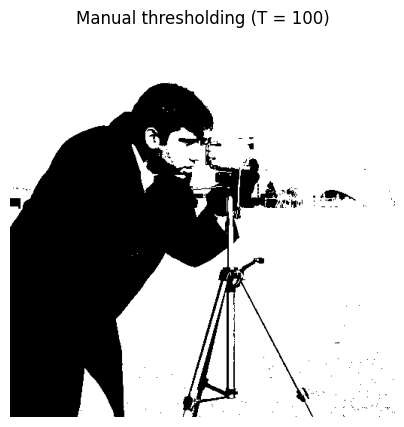

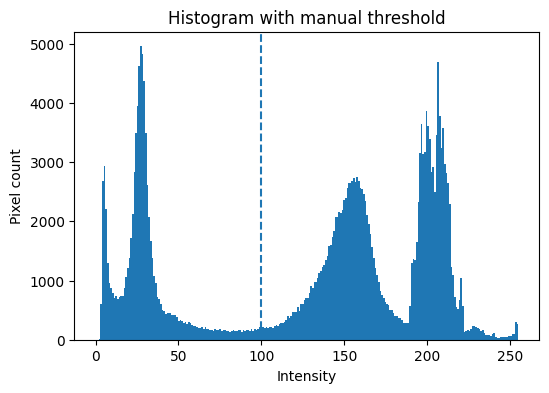

In [6]:
manual_threshold = 100
binary_manual = image > manual_threshold

show_image(binary_manual, f"Manual thresholding (T = {manual_threshold})")
show_histogram(image, threshold=manual_threshold, title="Histogram with manual threshold")

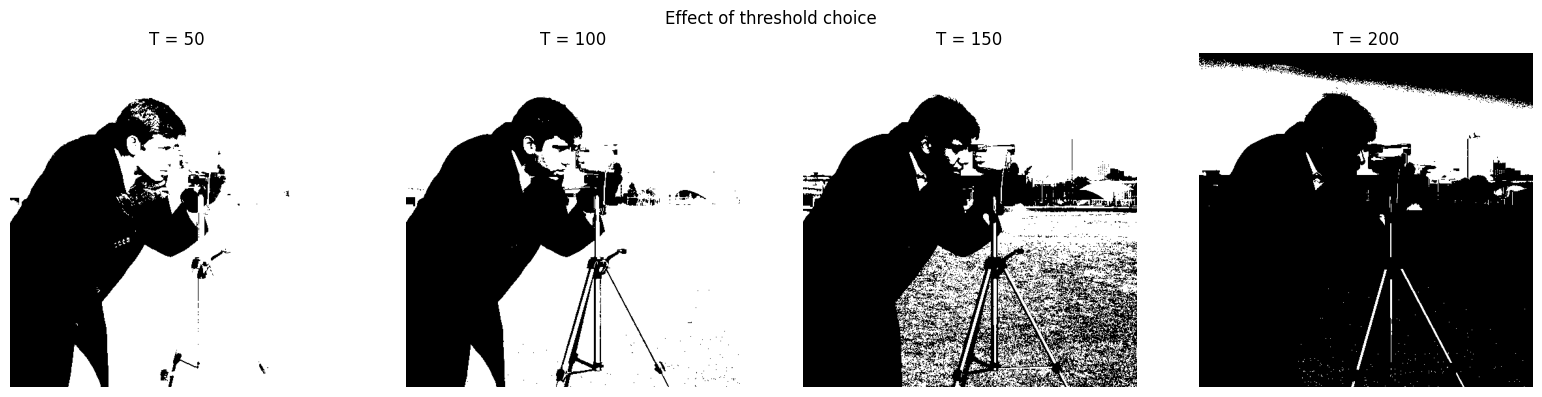

In [8]:
threshold_values = [50, 100, 150, 200]

fig, axes = plt.subplots(1, len(threshold_values), figsize=(16, 4))
for ax, t in zip(axes, threshold_values):
    ax.imshow(image > t, cmap="gray")
    ax.set_title(f"T = {t}")
    ax.axis("off")
plt.suptitle("Effect of threshold choice")
plt.tight_layout()
plt.savefig("../figures/figures_threshold_binary/manual_threshold.png", dpi=300, bbox_inches="tight")
plt.show()